In [1]:
# 라이브러리 import 및 데이터 불러오기
import pandas as pd

# 파일 경로
register_path = 'trial_register.csv'
visit_info_path = 'trial_visit_info.csv'
access_log_path = 'trial_access_log.csv'
payment_path = 'trial_payment.csv'
site_area_path = 'site_area.csv'

# 데이터 불러오기
df_register = pd.read_csv(register_path)
df_visit_info = pd.read_csv(visit_info_path)
df_access_log = pd.read_csv(access_log_path)
df_payment = pd.read_csv(payment_path)
df_site_area = pd.read_csv(site_area_path)

# 데이터프레임 리스트로 관리 (파일명과 동일하게)
dfs = {
    'trial_register': df_register,
    'trial_visit_info': df_visit_info,
    'trial_access_log': df_access_log,
    'trial_payment': df_payment,
    'site_area': df_site_area
}

In [2]:
# 각 데이터프레임의 기본 정보 확인
for name, df in dfs.items():
    print(f'===== {name} =====')
    print(f'Shape: {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    display(df.head(3))
    print('\n')

===== trial_register =====
Shape: (9659, 2)
Columns: ['trial_date', 'user_uuid']


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3




===== trial_visit_info =====
Shape: (11477, 7)
Columns: ['site_id', 'date', 'stay_time', 'stay_time_second', 'first_enter_time', 'last_leave_time', 'user_uuid']


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73




===== trial_access_log =====
Shape: (63708, 5)
Columns: ['id', 'checkin', 'cdate', 'site_id', 'user_uuid']


,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89




===== trial_payment =====
Shape: (9659, 2)
Columns: ['is_payment', 'user_uuid']


,is_payment,user_uuid
0,0,2b251333-8676-4c11-a736-dcf2350f8821
1,0,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,1,4a184795-b056-4572-a874-644f68609ea3




===== site_area =====
Shape: (9, 2)
Columns: ['site_id', 'area_pyeong']


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150


In [3]:
df_access_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63708 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         63708 non-null  int64 
 1   checkin    63708 non-null  int64 
 2   cdate      63708 non-null  object
 3   site_id    63708 non-null  int64 
 4   user_uuid  63708 non-null  object
dtypes: int64(3), object(2)
memory usage: 2.4+ MB


In [4]:
# 1. trial_register: 날짜형 변환
df_register['trial_date'] = pd.to_datetime(df_register['trial_date'])

# 2. trial_visit_info: 날짜/시간/수치형 변환
df_visit_info['date'] = pd.to_datetime(df_visit_info['date'])
df_visit_info['first_enter_time'] = pd.to_datetime(df_visit_info['first_enter_time'], errors='coerce')
df_visit_info['last_leave_time'] = pd.to_datetime(df_visit_info['last_leave_time'], errors='coerce')
df_visit_info['stay_time_second'] = pd.to_numeric(df_visit_info['stay_time_second'], errors='coerce')
df_visit_info = df_visit_info.drop(columns=['stay_time'])

# 3. trial_access_log: 날짜/시간 변환, checkin은 int, id는 int
df_access_log['cdate'] = pd.to_datetime(df_access_log['cdate'], errors='coerce')
df_access_log['checkin'] = pd.to_numeric(df_access_log['checkin'], errors='coerce').astype('Int64')
df_access_log['id'] = pd.to_numeric(df_access_log['id'], errors='coerce').astype('Int64')
df_access_log['site_id'] = pd.to_numeric(df_access_log['site_id'], errors='coerce').astype('Int64')

# 4. trial_payment: 결제여부 int 변환
df_payment['is_payment'] = pd.to_numeric(df_payment['is_payment'], errors='coerce').fillna(0).astype(int)

# 5. site_area: 면적 float 변환
df_site_area['site_id'] = pd.to_numeric(df_site_area['site_id'], errors='coerce').astype('Int64')
df_site_area['area_pyeong'] = pd.to_numeric(df_site_area['area_pyeong'], errors='coerce')

In [5]:
# 전처리 결과 점검: 데이터 타입, 결측치, 통계, 샘플
for name, df in dfs.items():
    print(f'===== {name} =====')
    print('컬럼별 데이터 타입:')
    print(df.dtypes)
    print('\n결측치 개수:')
    print(df.isnull().sum())
    print('\n기본 통계:')
    display(df.describe(include='all'))
    print('\n샘플 데이터:')
    display(df.head(3))
    print('-'*50)

===== trial_register =====
컬럼별 데이터 타입:
trial_date    datetime64[ns]
user_uuid             object
dtype: object

결측치 개수:
trial_date    0
user_uuid     0
dtype: int64

기본 통계:


,trial_date,user_uuid
count,9659,9659
unique,NaN,9624
top,NaN,dceba5c8-20c2-497a-829a-74099f7ee5a8
freq,NaN,2
mean,2022-08-09 23:32:34.115332864,NaN
min,2021-05-01 00:00:00,NaN
25%,2021-11-25 00:00:00,NaN
50%,2022-08-03 00:00:00,NaN
75%,2023-04-12 12:00:00,NaN
max,2023-12-31 00:00:00,NaN



샘플 데이터:


,trial_date,user_uuid
0,2023-12-21,2b251333-8676-4c11-a736-dcf2350f8821
1,2023-12-21,e111619a-0975-451b-9a4a-bc8aea7b7b84
2,2023-12-21,4a184795-b056-4572-a874-644f68609ea3


--------------------------------------------------
===== trial_visit_info =====
컬럼별 데이터 타입:
site_id                      int64
date                datetime64[ns]
stay_time                   object
stay_time_second             int64
first_enter_time    datetime64[ns]
last_leave_time     datetime64[ns]
user_uuid                   object
dtype: object

결측치 개수:
site_id                0
date                   0
stay_time              0
stay_time_second       0
first_enter_time    1353
last_leave_time     1330
user_uuid              0
dtype: int64

기본 통계:


...

--------------------------------------------------
===== site_area =====
컬럼별 데이터 타입:
site_id        Int64
area_pyeong    int64
dtype: object

결측치 개수:
site_id        0
area_pyeong    0
dtype: int64

기본 통계:


,site_id,area_pyeong
count,9.0,9.000000
mean,14.888889,94.444444
std,19.348414,46.398036
min,1.0,50.000000
25%,3.0,50.000000
50%,5.0,100.000000
75%,17.0,150.000000
max,49.0,150.000000



샘플 데이터:


,site_id,area_pyeong
0,1,50
1,2,100
2,3,150


--------------------------------------------------


In [6]:
user_feat_final.describe(include='all')

NameError: name 'user_feat_final' is not defined

In [11]:
# 1. trial_register: 유저별 신청일, 요일/시간/주말 파생
register_feat = df_register.copy()
register_feat['register_weekday'] = register_feat['trial_date'].dt.weekday
register_feat['register_is_weekend'] = register_feat['register_weekday'].isin([5,6]).astype(int)

# 2. trial_visit_info: 유저별 방문/체류 파생
visit = df_visit_info.copy()
visit['weekday'] = visit['date'].dt.weekday
visit['is_weekend'] = visit['weekday'].isin([5,6]).astype(int)
visit['hour'] = visit['first_enter_time'].dt.hour

visit_feat = visit.groupby('user_uuid').agg(
    visit_days = ('date', 'nunique'),
    total_stay_time = ('stay_time_second', 'sum'),
    avg_stay_time = ('stay_time_second', 'mean'),
    std_stay_time = ('stay_time_second', 'std'),
    first_visit_date = ('date', 'min'),
    visit_weekdays = ('is_weekend', lambda x: 1 - x.mean()),  # 평일 방문 비율
    visit_weekend = ('is_weekend', 'max'),  # 주말 방문 경험 여부
    site_count = ('site_id', 'nunique'),
    preferred_site_id = ('site_id', lambda x: x.value_counts().idxmax())
).reset_index()

# 오전/오후/야간 비율
def hour_type(hour):
    if 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 18: return 'afternoon'
    else: return 'night'
visit['hour_type'] = visit['hour'].apply(hour_type)
hour_pivot = visit.pivot_table(index='user_uuid', columns='hour_type', values='date', aggfunc='count', fill_value=0)
hour_pivot = hour_pivot.div(hour_pivot.sum(axis=1), axis=0).reset_index().rename_axis(None, axis=1)

visit_feat = visit_feat.merge(hour_pivot, on='user_uuid', how='left')

# 신청~첫 방문까지 소요 일수
register_feat = register_feat.merge(
    visit_feat[['user_uuid', 'first_visit_date']], on='user_uuid', how='left'
)
register_feat['first_visit_delay'] = (register_feat['first_visit_date'] - register_feat['trial_date']).dt.days
# 음수/결측/비정상값 마스킹 (예: -1, 0, 100일 이상 등)
register_feat['first_visit_delay'] = register_feat['first_visit_delay'].apply(lambda x: x if (x >= 0 and x < 100) else None)

# 3. trial_access_log: 입장/퇴장 카운트
access = df_access_log.copy()
entry_count = access[access['checkin'] == 1].groupby('user_uuid').size().rename('entry_count')
exit_count = access[access['checkin'] == 2].groupby('user_uuid').size().rename('exit_count')
access_feat = pd.concat([entry_count, exit_count], axis=1).fillna(0).reset_index()

# 4. site_area: 체류시간/면적, 넓은 지점만 방문 여부
visit_site = visit.merge(df_site_area, on='site_id', how='left')
site_density = visit_site.groupby('user_uuid').apply(
    lambda x: (x['stay_time_second'] / x['area_pyeong']).mean()
).rename('stay_density').reset_index()
# stay_density 이상치 마스킹 (음수, 99% 초과값 등)
q99 = site_density['stay_density'].quantile(0.99)
site_density['stay_density'] = site_density['stay_density'].apply(lambda x: x if (x >= 0 and x <= q99) else None)

big_site_ids = df_site_area[df_site_area['area_pyeong'] >= df_site_area['area_pyeong'].median()]['site_id']
is_big_site_user = visit_site.groupby('user_uuid')['site_id'].apply(
    lambda x: int(set(x).issubset(set(big_site_ids)))
).rename('is_big_site_user').reset_index()

# 5. 결제 타겟
target = df_payment[['user_uuid', 'is_payment']]

# 6. 통합
def safe_merge(left, right, **kwargs):
    # user_uuid 기준 중복 제거 후 merge
    return left.drop_duplicates('user_uuid').merge(right.drop_duplicates('user_uuid'), on='user_uuid', **kwargs)

user_feat = safe_merge(register_feat, visit_feat, how='left')
user_feat = safe_merge(user_feat, access_feat, how='left')
user_feat = safe_merge(user_feat, site_density, how='left')
user_feat = safe_merge(user_feat, is_big_site_user, how='left')
user_feat = safe_merge(user_feat, target, how='left')

user_feat = user_feat.fillna(0)

# preferred_site_id 범주형 인코딩 (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
user_feat['preferred_site_id_enc'] = le.fit_transform(user_feat['preferred_site_id'].astype(str))

# 날짜형 컬럼 제거 (trial_date, first_visit_date 등)
drop_cols = [col for col in user_feat.columns if any(x in col for x in ['date', 'trial_date', 'first_visit_date'])]
user_feat_final = user_feat.drop(columns=drop_cols)

# 최종 데이터 info/describe 점검
print('최종 user_feat_final info:')
user_feat_final.info()
print('\n최종 user_feat_final describe:')
display(user_feat_final.describe(include='all'))
user_feat_final.head()

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_11608\345756717.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  site_density = visit_site.groupby('user_uuid').apply(


최종 user_feat_final info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9624 entries, 0 to 9623
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_uuid              9624 non-null   object 
 1   register_weekday       9624 non-null   int32  
 2   register_is_weekend    9624 non-null   int32  
 3   first_visit_delay      9624 non-null   float64
 4   visit_days             9624 non-null   float64
 5   total_stay_time        9624 non-null   float64
 6   avg_stay_time          9624 non-null   float64
 7   std_stay_time          9624 non-null   float64
 8   visit_weekdays         9624 non-null   float64
 9   visit_weekend          9624 non-null   float64
 10  site_count             9624 non-null   float64
 11  preferred_site_id      9624 non-null   float64
 12  afternoon              9624 non-null   float64
 13  morning                9624 non-null   float64
 14  night                  9624 non

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
count,9624,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,...,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000,9624.000000
unique,9624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2b251333-8676-4c11-a736-dcf2350f8821,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.412406,0.153055,0.724958,1.175707,19902.841126,10739.263141,2309.558459,0.528464,0.205736,...,5.074190,0.328251,0.175987,0.174690,3.339983,3.279717,109.033206,0.487843,0.379468,3.301018
std,NaN,1.895376,0.360059,1.197393,1.053385,25226.304802,11417.214711,5123.380503,0.472328,0.404259,...,10.221637,0.433551,0.348350,0.349637,4.553783,4.491184,126.696372,0.499878,0.485280,3.211142
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,2.000000,0.000000,1.000000,1.000000,10944.500000,8427.500000,0.000000,0.666667,0.000000,...,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,73.883333,0.000000,0.000000,3.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,29751.500000,17774.500000,2463.736802,1.000000,0.000000,...,5.000000,1.000000,0.000000,0.000000,5.000000,5.000000,170.620833,1.000000,1.000000,5.000000


,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
0,2b251333-8676-4c11-a736-dcf2350f8821,3,0,0.0,1.0,19596.0,19596.0,0.0,1.0,0.0,...,49.0,0.0,1.0,0.0,6.0,6.0,391.92,0.0,0,7
1,e111619a-0975-451b-9a4a-bc8aea7b7b84,3,0,0.0,1.0,11084.0,11084.0,0.0,1.0,0.0,...,2.0,0.0,0.0,1.0,2.0,2.0,110.84,1.0,0,3
2,4a184795-b056-4572-a874-644f68609ea3,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,1,0
3,2ba8ab19-2d40-4423-ad04-f0f9ca814871,3,0,0.0,1.0,4775.0,4775.0,0.0,1.0,0.0,...,17.0,0.0,0.0,1.0,2.0,1.0,95.50,0.0,0,2
4,1d49ba36-6c23-405b-9514-aa7f4aeceff0,3,0,0.0,1.0,5037.0,5037.0,0.0,1.0,0.0,...,17.0,0.0,0.0,1.0,2.0,3.0,100.74,0.0,0,2


In [7]:
user_feat

NameError: name 'user_feat' is not defined

In [8]:
user_feat.info()

NameError: name 'user_feat' is not defined

In [2]:
from pytrends.request import TrendReq


In [9]:
from pytrends.request import TrendReq

# pytrends 객체 생성 (한국 시간 기준으로 설정)
pytrends = TrendReq(hl='ko', tz=540)

# 관심 키워드 설정
kw_list = ['공유오피스', '재택근무']

# 국가 및 시간 범위 설정
pytrends.build_payload(kw_list, 
                       cat=0, 
                       timeframe='2022-01-01 2023-12-31', 
                       geo='KR',         # ← 대한민국
                       gprop='')         # 웹 검색 기준

# 결과 가져오기
df = pytrends.interest_over_time()
df

,공유오피스,재택근무,isPartial
date,,,
2021-12-26,27,51,False
2022-01-02,43,59,False
2022-01-09,35,62,False
2022-01-16,34,53,False
2022-01-23,38,50,False
...,...,...,...
2023-12-03,34,31,False
2023-12-10,29,25,False
2023-12-17,28,24,False


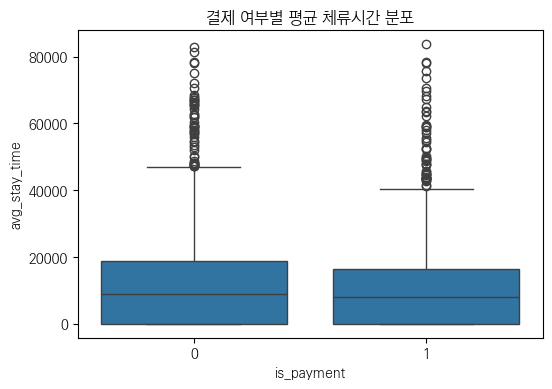

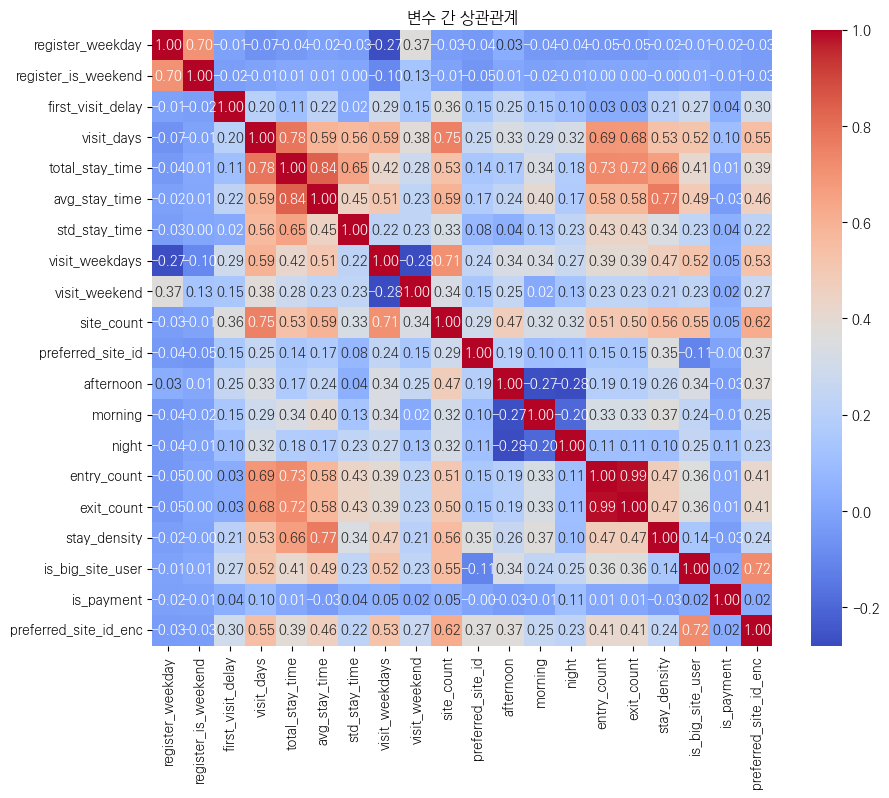

<Figure size 600x400 with 0 Axes>

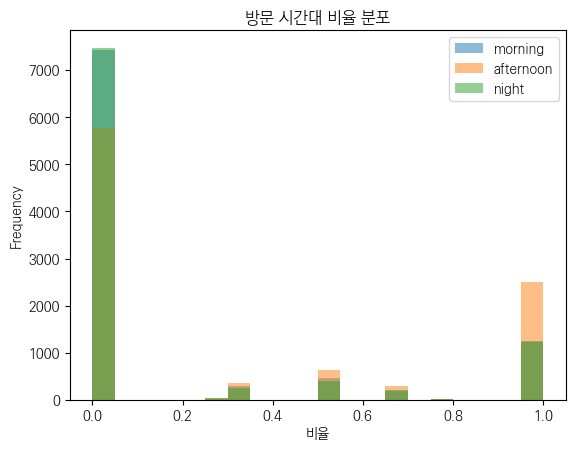

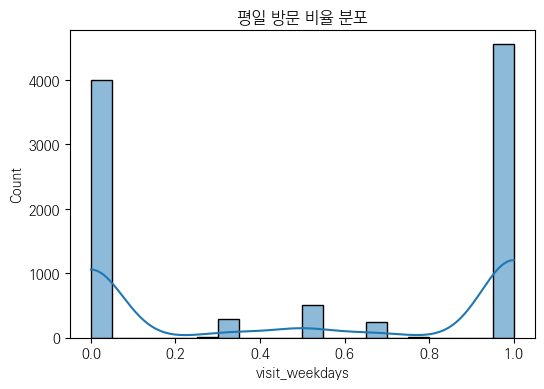

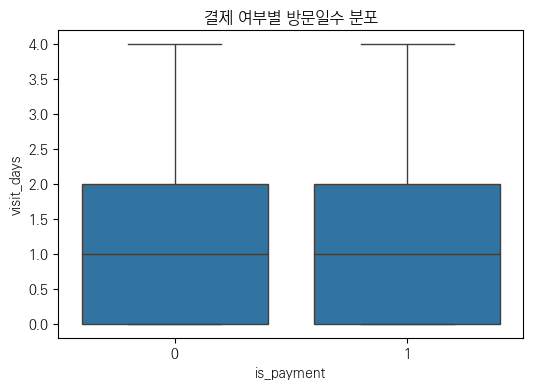

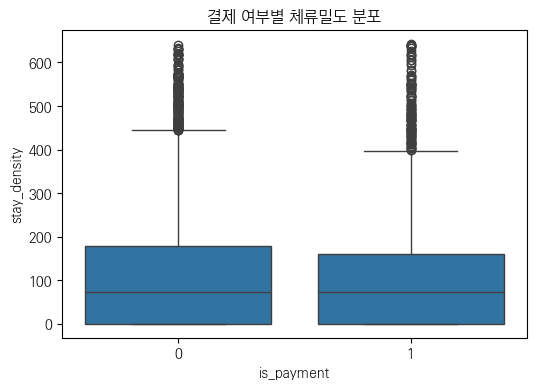

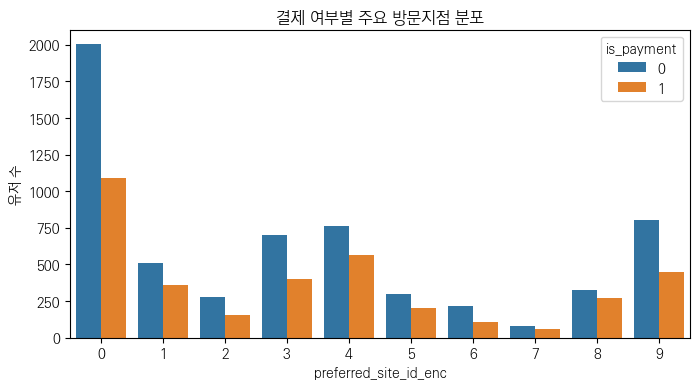

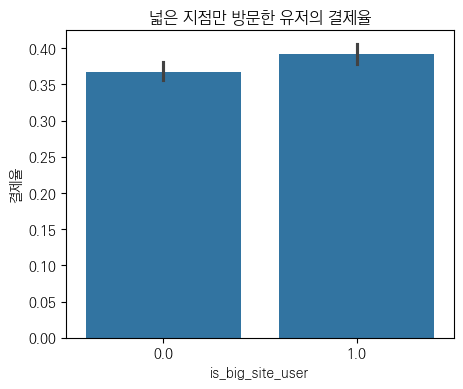

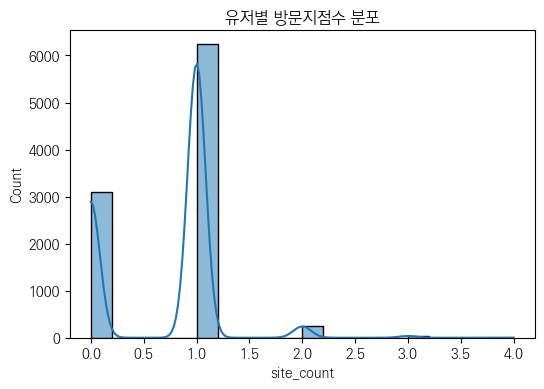

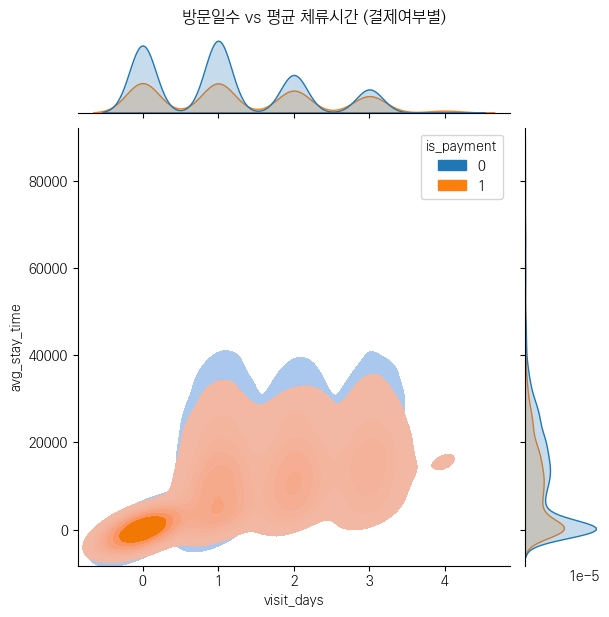

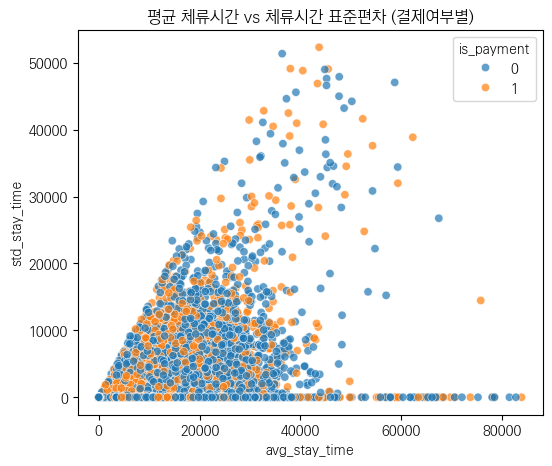

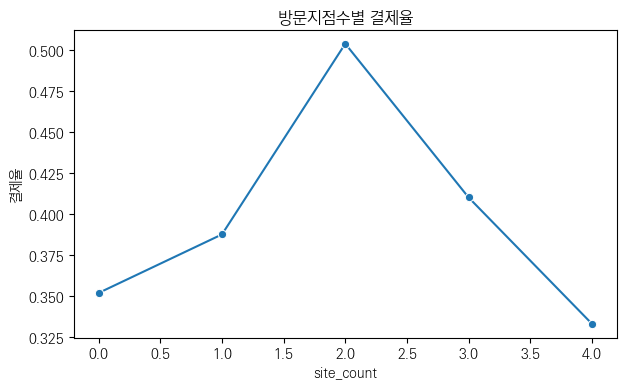

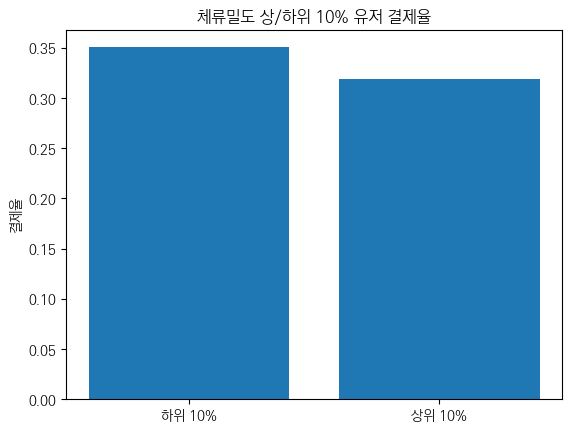

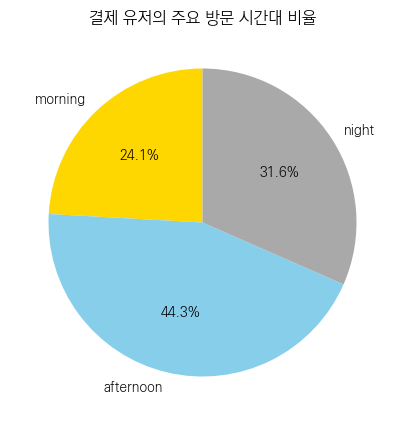

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 결제 여부별 평균 체류시간 분포
plt.figure(figsize=(6,4))
sns.boxplot(x='is_payment', y='avg_stay_time', data=user_feat_final)
plt.title('결제 여부별 평균 체류시간 분포')
plt.xlabel('is_payment')
plt.ylabel('avg_stay_time')
plt.show()

# 2. 주요 변수 상관관계 heatmap
numeric_cols = user_feat_final.select_dtypes(include=['number']).columns
plt.figure(figsize=(10,8))
sns.heatmap(user_feat_final[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('변수 간 상관관계')
plt.show()

# 3. 방문 시간대 비율 분포
plt.figure(figsize=(6,4))
user_feat_final[['morning','afternoon','night']].plot(kind='hist', alpha=0.5, bins=20)
plt.title('방문 시간대 비율 분포')
plt.xlabel('비율')
plt.show()

# 4. 평일 방문 비율 분포
plt.figure(figsize=(6,4))
sns.histplot(user_feat_final['visit_weekdays'], bins=20, kde=True)
plt.title('평일 방문 비율 분포')
plt.xlabel('visit_weekdays')
plt.show()

# 5. 결제 여부별 방문일수(visit_days) 분포
plt.figure(figsize=(6,4))
sns.boxplot(x='is_payment', y='visit_days', data=user_feat_final)
plt.title('결제 여부별 방문일수 분포')
plt.xlabel('is_payment')
plt.ylabel('visit_days')
plt.show()

# 6. 결제 여부별 체류밀도(stay_density) 분포
plt.figure(figsize=(6,4))
sns.boxplot(x='is_payment', y='stay_density', data=user_feat_final)
plt.title('결제 여부별 체류밀도 분포')
plt.xlabel('is_payment')
plt.ylabel('stay_density')
plt.show()

# 7. 결제 여부별 주요 방문지점(preferred_site_id_enc) 분포
plt.figure(figsize=(8,4))
sns.countplot(x='preferred_site_id_enc', hue='is_payment', data=user_feat_final)
plt.title('결제 여부별 주요 방문지점 분포')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('유저 수')
plt.legend(title='is_payment')
plt.show()

# 8. is_big_site_user에 따른 결제율
plt.figure(figsize=(5,4))
sns.barplot(x='is_big_site_user', y='is_payment', data=user_feat_final)
plt.title('넓은 지점만 방문한 유저의 결제율')
plt.xlabel('is_big_site_user')
plt.ylabel('결제율')
plt.show()

# 9. site_count(방문지점수) 분포
plt.figure(figsize=(6,4))
sns.histplot(user_feat_final['site_count'], bins=20, kde=True)
plt.title('유저별 방문지점수 분포')
plt.xlabel('site_count')
plt.show()

# 10. 결제 유저/비결제 유저의 체류시간-방문일수 jointplot (패턴 군집 시각화)
sns.jointplot(x='visit_days', y='avg_stay_time', data=user_feat_final, hue='is_payment', kind='kde', fill=True, height=6)
plt.suptitle('방문일수 vs 평균 체류시간 (결제여부별)', y=1.02)
plt.show()

# 11. 체류시간 표준편차 vs 평균 체류시간 (유저별 일관성/패턴)
plt.figure(figsize=(6,5))
sns.scatterplot(x='avg_stay_time', y='std_stay_time', hue='is_payment', data=user_feat_final, alpha=0.7)
plt.title('평균 체류시간 vs 체류시간 표준편차 (결제여부별)')
plt.xlabel('avg_stay_time')
plt.ylabel('std_stay_time')
plt.legend(title='is_payment')
plt.show()

# 12. site_count(방문지점수)별 결제율
site_count_pay = user_feat_final.groupby('site_count')['is_payment'].mean().reset_index()
plt.figure(figsize=(7,4))
sns.lineplot(x='site_count', y='is_payment', data=site_count_pay, marker='o')
plt.title('방문지점수별 결제율')
plt.xlabel('site_count')
plt.ylabel('결제율')
plt.show()

# 13. stay_density(체류밀도) 상위/하위 10% 유저의 결제율 비교
q10 = user_feat_final['stay_density'].quantile(0.1)
q90 = user_feat_final['stay_density'].quantile(0.9)
low = user_feat_final[user_feat_final['stay_density'] <= q10]['is_payment']
high = user_feat_final[user_feat_final['stay_density'] >= q90]['is_payment']
plt.bar(['하위 10%', '상위 10%'], [low.mean(), high.mean()])
plt.title('체류밀도 상/하위 10% 유저 결제율')
plt.ylabel('결제율')
plt.show()

# 14. 결제 유저의 주요 방문 시간대 비율 (pie chart)
pay_time = user_feat_final[user_feat_final['is_payment']==1][['morning','afternoon','night']].mean()
plt.figure(figsize=(5,5))
plt.pie(pay_time, labels=pay_time.index, autopct='%1.1f%%', startangle=90, colors=['#FFD700','#87CEEB','#A9A9A9'])
plt.title('결제 유저의 주요 방문 시간대 비율')
plt.show()

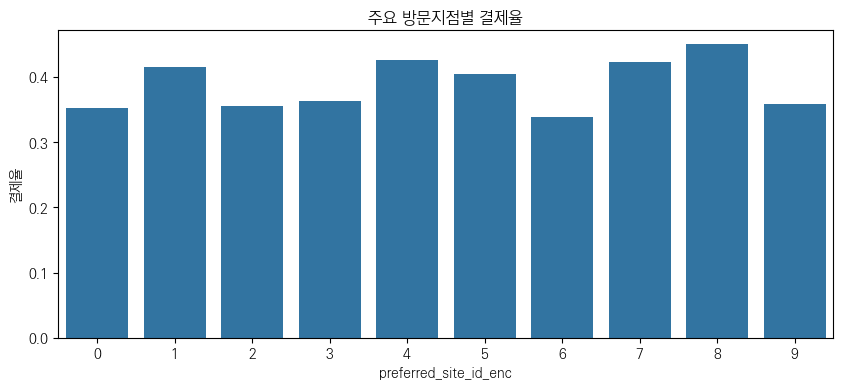

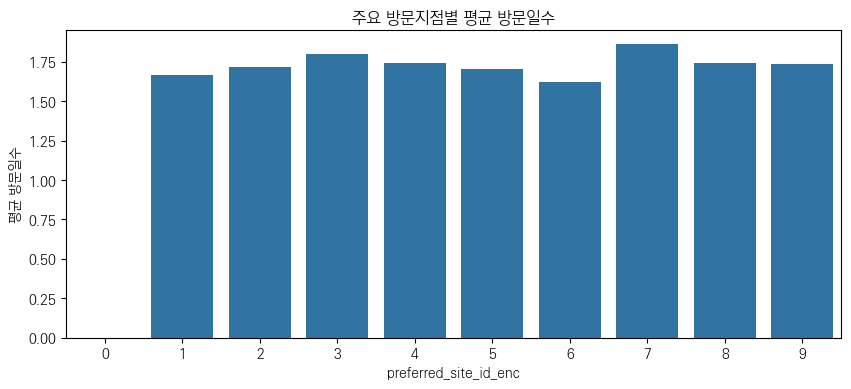

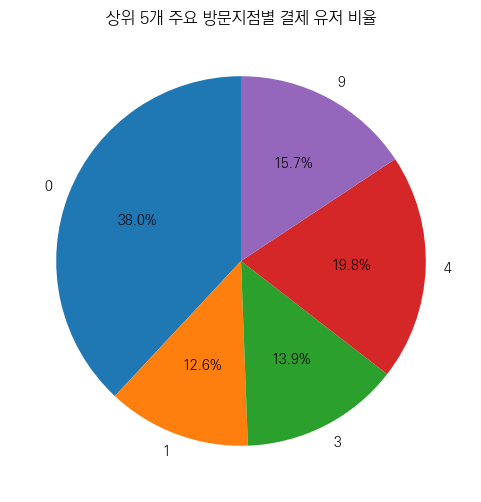

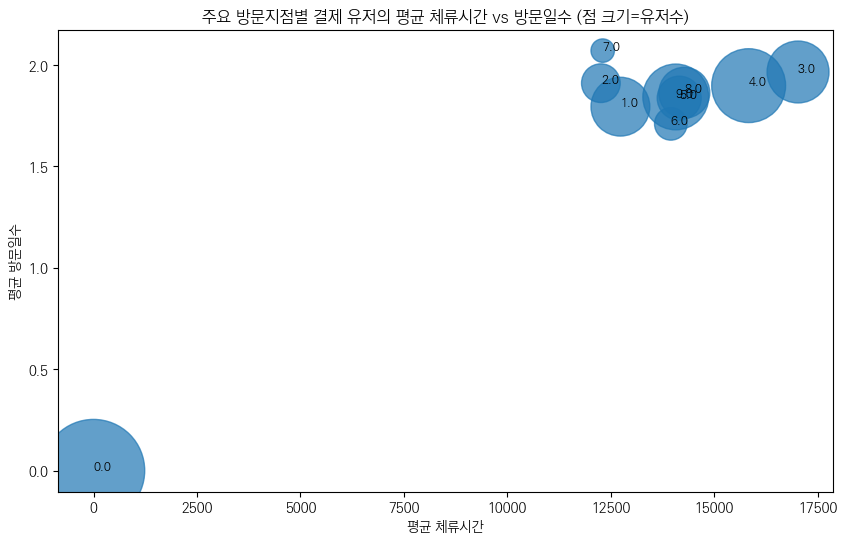

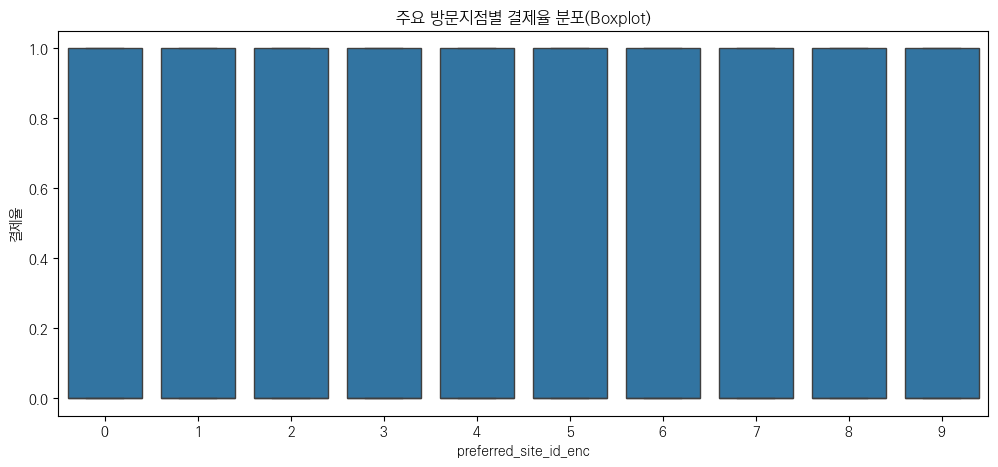

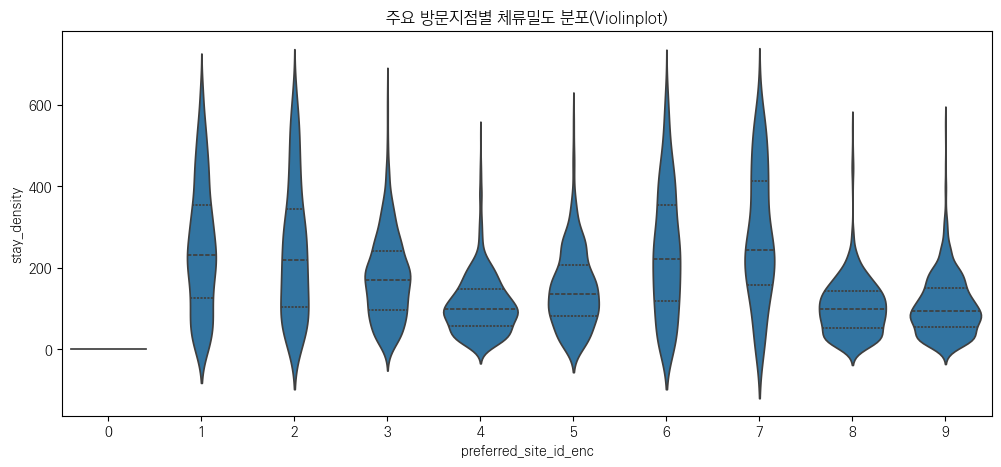

In [18]:
# 방문지점별(주요 방문지점) 결제율 및 주요 통계 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 주요 방문지점별 결제율 barplot
site_pay = user_feat_final.groupby('preferred_site_id_enc')['is_payment'].mean().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(x='preferred_site_id_enc', y='is_payment', data=site_pay)
plt.title('주요 방문지점별 결제율')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('결제율')
plt.show()

# 2. 주요 방문지점별 평균 방문일수 barplot
site_visit = user_feat_final.groupby('preferred_site_id_enc')['visit_days'].mean().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(x='preferred_site_id_enc', y='visit_days', data=site_visit)
plt.title('주요 방문지점별 평균 방문일수')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('평균 방문일수')
plt.show()

# 3. 주요 방문지점별 결제 유저 비율 pie chart (상위 5개만)
top5 = user_feat_final['preferred_site_id_enc'].value_counts().head(5).index
pie_data = user_feat_final[user_feat_final['preferred_site_id_enc'].isin(top5)]
pay_counts = pie_data.groupby('preferred_site_id_enc')['is_payment'].sum()
plt.figure(figsize=(6,6))
plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('상위 5개 주요 방문지점별 결제 유저 비율')
plt.show()

# 4. 주요 방문지점별 결제 유저의 평균 체류시간/방문일수 산점도
site_group = user_feat_final[user_feat_final['is_payment']==1].groupby('preferred_site_id_enc').agg({'avg_stay_time':'mean','visit_days':'mean','user_uuid':'count'}).reset_index()
plt.figure(figsize=(10,6))
plt.scatter(site_group['avg_stay_time'], site_group['visit_days'], s=site_group['user_uuid']*5, alpha=0.7)
for i, row in site_group.iterrows():
    plt.text(row['avg_stay_time'], row['visit_days'], str(row['preferred_site_id_enc']), fontsize=9)
plt.title('주요 방문지점별 결제 유저의 평균 체류시간 vs 방문일수 (점 크기=유저수)')
plt.xlabel('평균 체류시간')
plt.ylabel('평균 방문일수')
plt.show()

# 5. 주요 방문지점별 결제율 boxplot (지점별 분포)
plt.figure(figsize=(12,5))
sns.boxplot(x='preferred_site_id_enc', y='is_payment', data=user_feat_final)
plt.title('주요 방문지점별 결제율 분포(Boxplot)')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('결제율')
plt.show()

# 6. 주요 방문지점별 체류밀도(stay_density) 분포 violinplot
plt.figure(figsize=(12,5))
sns.violinplot(x='preferred_site_id_enc', y='stay_density', data=user_feat_final, inner='quartile')
plt.title('주요 방문지점별 체류밀도 분포(Violinplot)')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('stay_density')
plt.show()

[LightGBM] [Info] Number of positive: 2922, number of negative: 4777
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 7699, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.379530 -> initscore=-0.491544
[LightGBM] [Info] Start training from score -0.491544
[LightGBM] [Info] Number of positive: 2922, number of negative: 4777
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 7699, number of used features: 19
[LightGBM] [Info] [binar

,Model,Accuracy,AUC,F1
0,VotingEnsemble,0.644156,0.600413,0.319762
1,GradientBoosting,0.646753,0.594788,0.306122
2,LogisticRegression,0.649351,0.593649,0.290221
3,LightGBM,0.634286,0.590500,0.302970
4,RandomForest,0.637922,0.589619,0.345540
5,XGBoost,0.631169,0.581538,0.347426


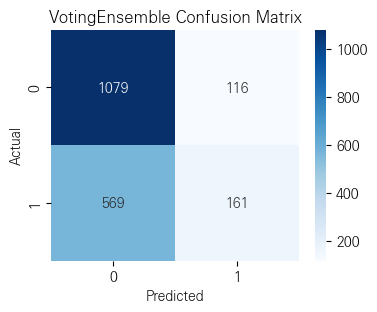

In [21]:
# 머신러닝 모델링: 여러 모델, 앙상블, 성능 비교
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 준비 (feature/target 분리, train/valid split)
X = user_feat_final.drop(columns=['user_uuid', 'is_payment'])
y = user_feat_final['is_payment']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 스케일링 (LogisticRegression만 적용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# 3. 여러 모델 정의
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42)
}

# 4. 모델별 학습 및 평가
results = []
for name, model in models.items():
    if name == 'LogisticRegression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_valid_scaled)
        y_proba = model.predict_proba(X_valid_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_valid)
        y_proba = model.predict_proba(X_valid)[:,1]
    acc = accuracy_score(y_valid, y_pred)
    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'AUC': auc, 'F1': f1})

# 5. 앙상블(Voting) 모델
voting = VotingClassifier(
    estimators=[
        ('rf', models['RandomForest']),
        ('gb', models['GradientBoosting']),
        ('xgb', models['XGBoost']),
        ('lgbm', models['LightGBM'])
    ],
    voting='soft'
)
voting.fit(X_train, y_train)
y_pred = voting.predict(X_valid)
y_proba = voting.predict_proba(X_valid)[:,1]
acc = accuracy_score(y_valid, y_pred)
auc = roc_auc_score(y_valid, y_proba)
f1 = f1_score(y_valid, y_pred)
results.append({'Model': 'VotingEnsemble', 'Accuracy': acc, 'AUC': auc, 'F1': f1})

# 6. 결과 표 출력
score_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print('모델별 성능 비교 (Validation Set)')
display(score_df)

# 7. 최고 성능 모델 confusion matrix 시각화
best_model_name = score_df.iloc[0]['Model']
if best_model_name == 'VotingEnsemble':
    best_model = voting
    y_pred_best = y_pred
else:
    best_model = models[best_model_name]
    if best_model_name == 'LogisticRegression':
        y_pred_best = best_model.predict(X_valid_scaled)
    else:
        y_pred_best = best_model.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

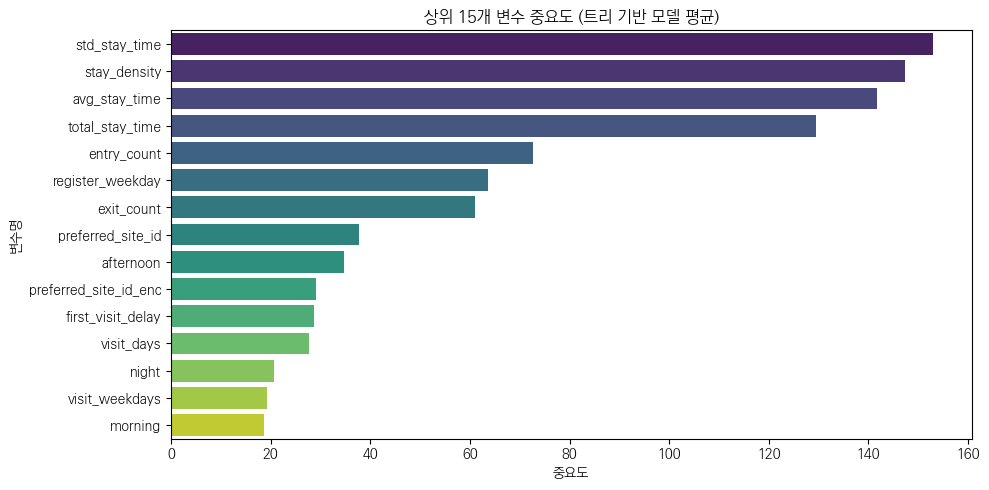

,feature,importance
0,std_stay_time,153.044228
1,stay_density,147.399305
2,avg_stay_time,141.735780
3,total_stay_time,129.397251
4,entry_count,72.703369
5,register_weekday,63.701487
6,exit_count,61.039457
7,preferred_site_id,37.695617
8,afternoon,34.690535
9,preferred_site_id_enc,29.028043


In [22]:
# === 모델 feature importance 시각화 ===
# 앙상블(VotingEnsemble)에서 트리 기반 모델(RandomForest, XGBoost, LightGBM) feature importance 평균
import numpy as np

feature_names = X.columns
importances = []

for name in ['RandomForest', 'XGBoost', 'LightGBM']:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        importances.append(model.feature_importances_)
    else:
        importances.append(np.zeros(len(feature_names)))

mean_importance = np.mean(importances, axis=0)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=importance_df.head(15), palette='viridis')
plt.title('상위 15개 변수 중요도 (트리 기반 모델 평균)')
plt.xlabel('중요도')
plt.ylabel('변수명')
plt.tight_layout()
plt.show()

# 전체 변수 중요도 표도 함께 출력
importance_df.reset_index(drop=True, inplace=True)
display(importance_df.head(30))

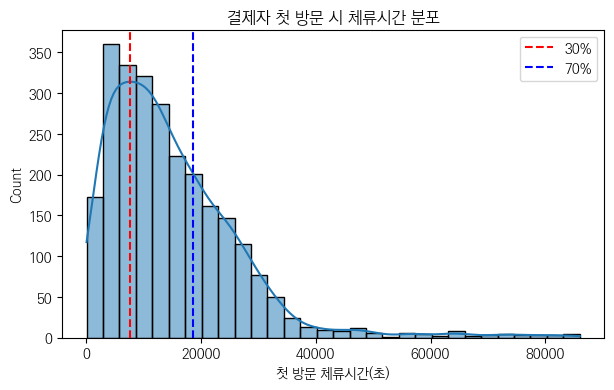

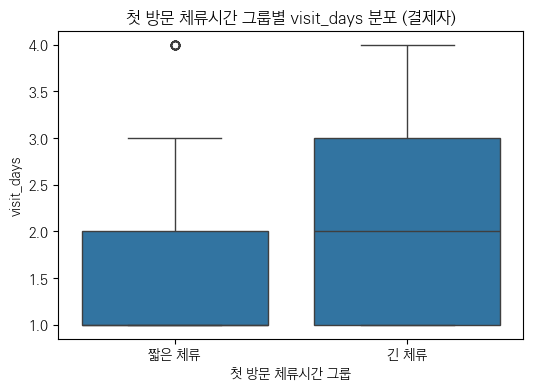

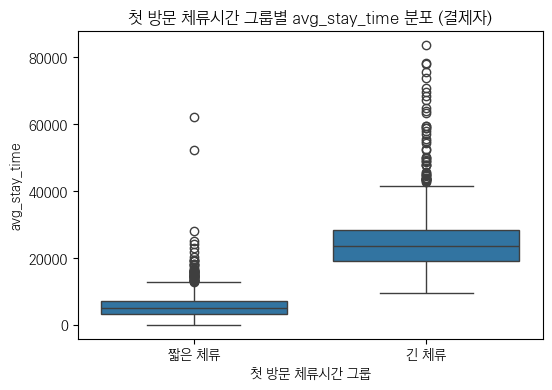

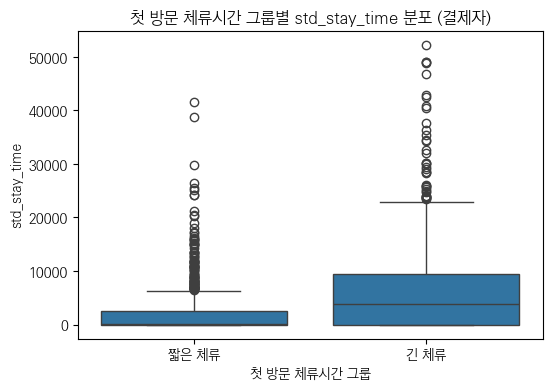

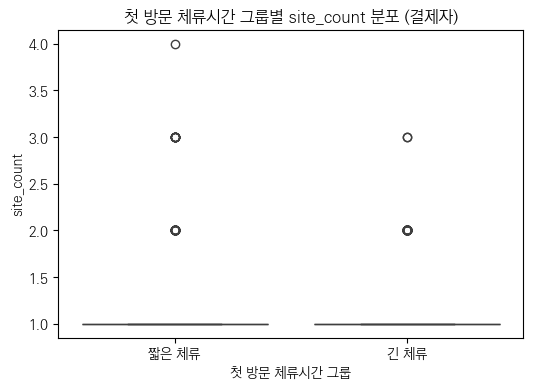

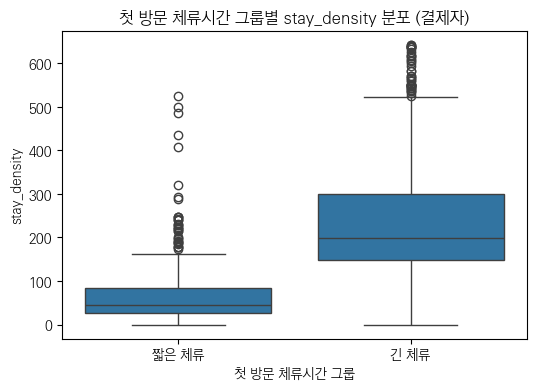

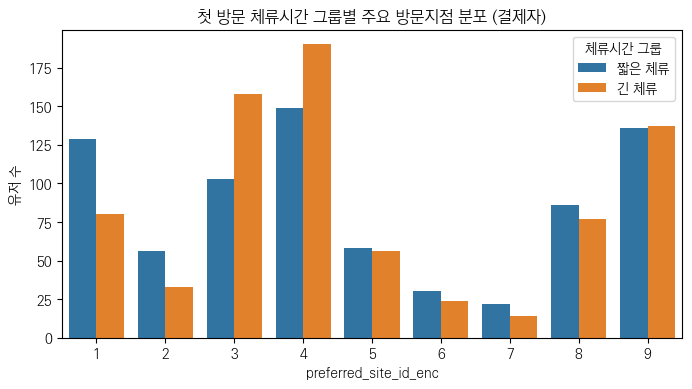

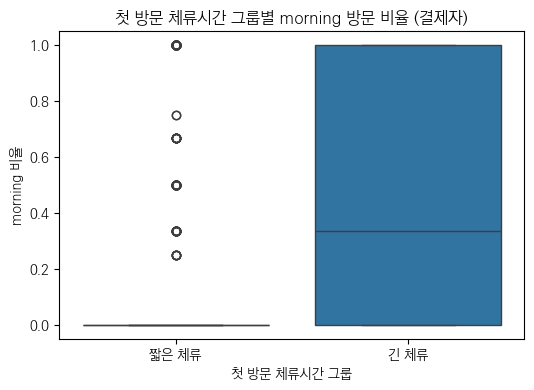

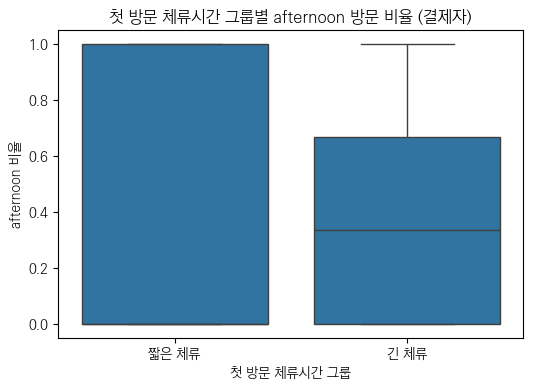

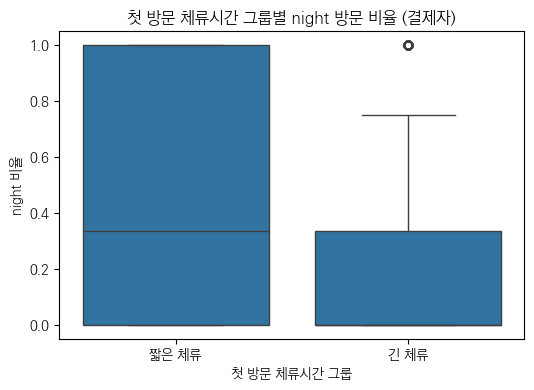

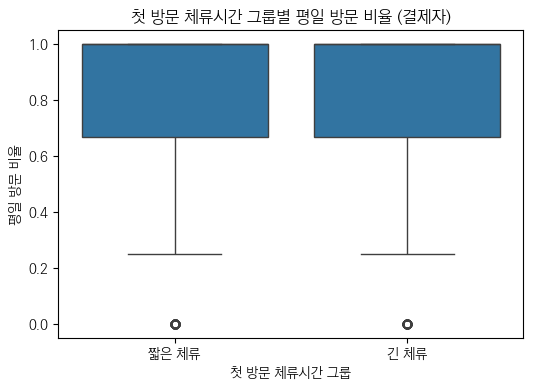

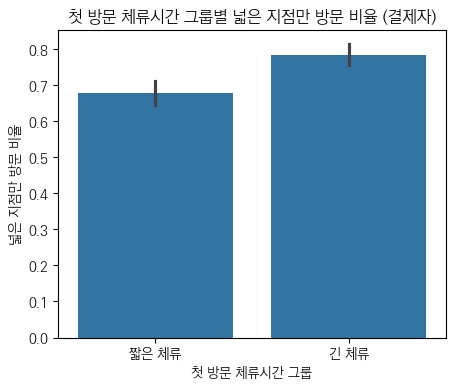

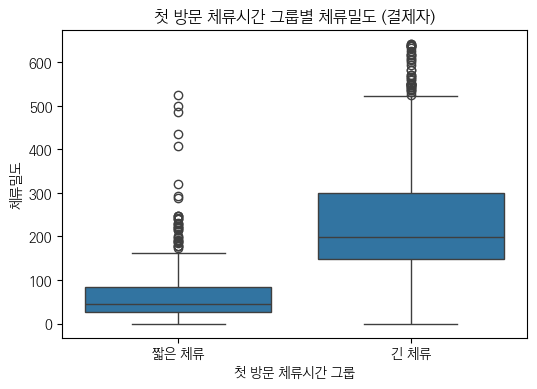

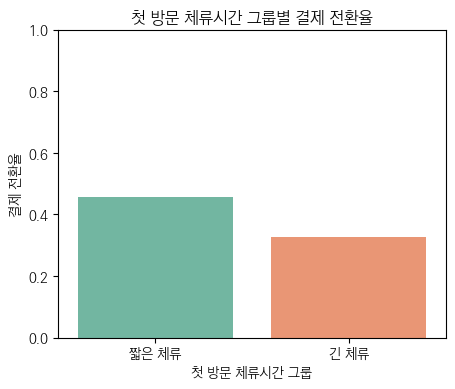

첫 방문 체류시간 그룹별 결제 전환율(%)


,stay_group,is_payment
0,긴 체류,0.325854
1,짧은 체류,0.455102


In [24]:
# 결제자 중 첫 방문 시 체류시간이 긴 유저 vs 짧은 유저 비교 EDA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 결제자만 추출
paid = user_feat_final[user_feat_final['is_payment'] == 1].copy()

# 2. 첫 방문 시 체류시간 컬럼(visit_first_stay_time) 생성
# 원본 visit 데이터에서 첫 방문일 기준 체류시간 추출
first_stay = visit.groupby('user_uuid').apply(lambda x: x.loc[x['date'].idxmin(), 'stay_time_second']).reset_index()
first_stay.columns = ['user_uuid', 'first_stay_time']
paid = paid.merge(first_stay, on='user_uuid', how='left')

# 3. 체류시간 기준 상/하위 30%로 그룹 나누기
q30 = paid['first_stay_time'].quantile(0.3)
q70 = paid['first_stay_time'].quantile(0.7)
paid['stay_group'] = np.where(paid['first_stay_time'] <= q30, '짧은 체류',
                        np.where(paid['first_stay_time'] >= q70, '긴 체류', '중간'))

# 4. 체류시간 분포 시각화
plt.figure(figsize=(7,4))
sns.histplot(paid['first_stay_time'], bins=30, kde=True)
plt.axvline(q30, color='r', linestyle='--', label='30%')
plt.axvline(q70, color='b', linestyle='--', label='70%')
plt.title('결제자 첫 방문 시 체류시간 분포')
plt.xlabel('첫 방문 체류시간(초)')
plt.legend()
plt.show()

# 5. 긴 체류 vs 짧은 체류 유저의 주요 변수 비교 (boxplot)
compare_cols = ['visit_days', 'avg_stay_time', 'std_stay_time', 'site_count', 'stay_density']
for col in compare_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='stay_group', y=col, data=paid[paid['stay_group'] != '중간'])
    plt.title(f'첫 방문 체류시간 그룹별 {col} 분포 (결제자)')
    plt.xlabel('첫 방문 체류시간 그룹')
    plt.ylabel(col)
    plt.show()

# 6. 주요 방문지점 분포
plt.figure(figsize=(8,4))
sns.countplot(x='preferred_site_id_enc', hue='stay_group', data=paid[paid['stay_group'] != '중간'])
plt.title('첫 방문 체류시간 그룹별 주요 방문지점 분포 (결제자)')
plt.xlabel('preferred_site_id_enc')
plt.ylabel('유저 수')
plt.legend(title='체류시간 그룹')
plt.show()

# 7. 시간대별 방문 비율 비교
for time_col in ['morning', 'afternoon', 'night']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='stay_group', y=time_col, data=paid[paid['stay_group'] != '중간'])
    plt.title(f'첫 방문 체류시간 그룹별 {time_col} 방문 비율 (결제자)')
    plt.xlabel('첫 방문 체류시간 그룹')
    plt.ylabel(f'{time_col} 비율')
    plt.show()

# 8. 평일 방문 비율, 넓은 지점 방문 여부, 체류밀도 등도 비교
plt.figure(figsize=(6,4))
sns.boxplot(x='stay_group', y='visit_weekdays', data=paid[paid['stay_group'] != '중간'])
plt.title('첫 방문 체류시간 그룹별 평일 방문 비율 (결제자)')
plt.xlabel('첫 방문 체류시간 그룹')
plt.ylabel('평일 방문 비율')
plt.show()

plt.figure(figsize=(5,4))
sns.barplot(x='stay_group', y='is_big_site_user', data=paid[paid['stay_group'] != '중간'])
plt.title('첫 방문 체류시간 그룹별 넓은 지점만 방문 비율 (결제자)')
plt.xlabel('첫 방문 체류시간 그룹')
plt.ylabel('넓은 지점만 방문 비율')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='stay_group', y='stay_density', data=paid[paid['stay_group'] != '중간'])
plt.title('첫 방문 체류시간 그룹별 체류밀도 (결제자)')
plt.xlabel('첫 방문 체류시간 그룹')
plt.ylabel('체류밀도')
plt.show()

# 짧은 체류, 긴 체류 그룹의 전환율(결제율) 차이 시각화
# 전체 유저 중 첫 방문 체류시간 기준 그룹 나누기
first_stay_all = visit.groupby('user_uuid').apply(lambda x: x.loc[x['date'].idxmin(), 'stay_time_second']).reset_index()
first_stay_all.columns = ['user_uuid', 'first_stay_time']
user_group = user_feat_final.merge(first_stay_all, on='user_uuid', how='left')

q30 = user_group['first_stay_time'].quantile(0.3)
q70 = user_group['first_stay_time'].quantile(0.7)
user_group['stay_group'] = np.where(user_group['first_stay_time'] <= q30, '짧은 체류',
                              np.where(user_group['first_stay_time'] >= q70, '긴 체류', '중간'))

# 그룹별 결제율 계산
conv = user_group[user_group['stay_group'] != '중간'].groupby('stay_group')['is_payment'].mean().reset_index()

plt.figure(figsize=(5,4))
sns.barplot(x='stay_group', y='is_payment', data=conv, order=['짧은 체류','긴 체류'], palette='Set2')
plt.title('첫 방문 체류시간 그룹별 결제 전환율')
plt.xlabel('첫 방문 체류시간 그룹')
plt.ylabel('결제 전환율')
plt.ylim(0, 1)
plt.show()

# 수치도 함께 출력
print('첫 방문 체류시간 그룹별 결제 전환율(%)')
display(conv)

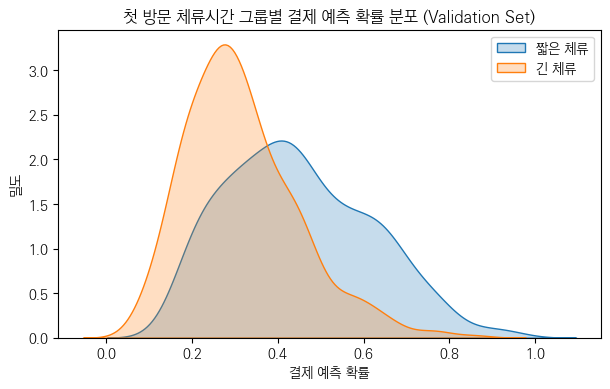

첫 방문 체류시간 그룹별 평균 결제 예측 확률


,stay_group,pred_proba
0,긴 체류,0.314782
1,짧은 체류,0.447585


In [25]:
# 머신러닝 예측값 기반으로 첫 방문 체류시간 그룹별 결제 확률(예측값) 분포 시각화
# (긴 체류/짧은 체류 그룹별 모델의 예측 확률 분포를 비교)

# 최고 성능 모델(best_model)에서 predict_proba로 결제 확률 추출
if best_model_name == 'LogisticRegression':
    y_pred_proba = best_model.predict_proba(X_valid_scaled)[:,1]
else:
    y_pred_proba = best_model.predict_proba(X_valid)[:,1]

# X_valid에 user_uuid, 첫 방문 체류시간 정보 붙이기 (user_feat_final 인덱스와 X_valid 인덱스가 일치한다고 가정)
valid_idx = X_valid.index
valid_user = user_feat_final.iloc[valid_idx].copy()

# 첫 방문 체류시간 정보 추가
first_stay_valid = visit.groupby('user_uuid').apply(lambda x: x.loc[x['date'].idxmin(), 'stay_time_second']).reset_index()
first_stay_valid.columns = ['user_uuid', 'first_stay_time']
valid_user = valid_user.merge(first_stay_valid, on='user_uuid', how='left')

# 그룹 나누기
q30 = valid_user['first_stay_time'].quantile(0.3)
q70 = valid_user['first_stay_time'].quantile(0.7)
valid_user['stay_group'] = np.where(valid_user['first_stay_time'] <= q30, '짧은 체류',
                              np.where(valid_user['first_stay_time'] >= q70, '긴 체류', '중간'))
valid_user['pred_proba'] = y_pred_proba

# 긴/짧은 체류 그룹별 예측 결제확률 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,4))
sns.kdeplot(data=valid_user[valid_user['stay_group']=='짧은 체류'], x='pred_proba', label='짧은 체류', fill=True)
sns.kdeplot(data=valid_user[valid_user['stay_group']=='긴 체류'], x='pred_proba', label='긴 체류', fill=True)
plt.title('첫 방문 체류시간 그룹별 결제 예측 확률 분포 (Validation Set)')
plt.xlabel('결제 예측 확률')
plt.ylabel('밀도')
plt.legend()
plt.show()

# 그룹별 평균 예측 확률도 출력
print('첫 방문 체류시간 그룹별 평균 결제 예측 확률')
display(valid_user[valid_user['stay_group'].isin(['짧은 체류','긴 체류'])].groupby('stay_group')['pred_proba'].mean().reset_index())